# 03 — Time-Delay Embedding (TDE)

Estimates embedding parameters `τ` (AMI) and `m` (FNN) for each trial, then aggregates them per participant by taking the median across the 3 conditions.

## Signal used

`signal_final` (100 Hz) with the **perturbation zone excluded**: concatenation of pre-perturbation `[start, entry − 5 s]` and post-perturbation `[exit + 30 s, end]`. Yields ~525–630 cycles per trial, well above the 200-cycle minimum (Mehdizadeh 2020).

## Parameters

| Parameter | Value | Source |
|---|---|---|
| `max_lag` | 100 (= 1 s at 100 Hz) | — |
| `max_dim` | 10 | — |
| `r_threshold` | 15 | Kennel et al. 1992 |
| `fnn_threshold` | 10 % | Mehdizadeh 2020 |
| `τ` | first local minimum of AMI | Fraser & Swinney 1986 |
| `m` | first dim with FNN rate < 10 % | Kennel 1992 |

## Aggregation

`τ_p = round(median(τ_sil, τ_tr, τ_bm))`, `m_p = round(median(m_sil, m_tr, m_bm))`. Assumption: `τ` and `m` are subject-level properties.

## Inputs / Outputs

- **Input**  : `data/processed/*.npz`
- **Output** : `outputs/tables/03_tde_per_trial.csv`, `outputs/tables/03_tde_per_participant.csv`, `outputs/figures/03_{ami,fnn}_curves.png`, `outputs/figures/03_distributions.png`

In [2]:
from resilience import paths
from resilience.analysis import tde_workflow
from resilience.viz import plots

from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

OUT_FIGURES = Path(paths.OUTPUTS_DIR) / 'figures'

## 1. Run pipeline

In [3]:
trials = tde_workflow.load_trials_with_detection()
print(f"✅ {len(trials)} trials loaded\n")

df_tde, curves = tde_workflow.compute_tde_per_trial(trials)
df_p = tde_workflow.aggregate_per_participant(df_tde)

C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\tde_workflow.py:83: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)


✅ 38 trials loaded

  001CrMa/silence               : τ= 17, m=4, n_cycles≈665
  001CrMa/tempo_random          : τ= 16, m=4, n_cycles≈666
  001CrMa/beatmove_adaptatif    : τ= 16, m=4, n_cycles≈452
  002CrPa/silence               : τ= 17, m=4, n_cycles≈665
  002CrPa/beatmove_adaptatif    : τ= 17, m=4, n_cycles≈560
  002CrPa/tempo_random          : τ= 17, m=4, n_cycles≈630
  003BrLu/silence               : τ= 16, m=4, n_cycles≈645
  003BrLu/tempo_random          : τ= 18, m=4, n_cycles≈527
  003BrLu/beatmove_adaptatif    : τ= 18, m=4, n_cycles≈666
  004CaGe/silence               : τ= 18, m=4, n_cycles≈654
  004CaGe/tempo_random          : τ= 16, m=4, n_cycles≈596
  004CaGe/beatmove_adaptatif    : τ= 17, m=4, n_cycles≈666
  005DeJe/tempo_random          : τ= 16, m=4, n_cycles≈562
  005DeJe/beatmove_adaptatif    : τ= 16, m=4, n_cycles≈405
  006MoCa/silence               : τ= 16, m=4, n_cycles≈572
  006MoCa/tempo_random          : τ= 15, m=4, n_cycles≈314
  006MoCa/beatmove_adaptatif    : τ=

## 2. Inspect results

In [4]:
df_p[['participant', 'n_trials', 'tau_min', 'tau_med', 'tau_max', 'tau_range',
      'm_min', 'm_med', 'm_max', 'm_range', 'tau_p', 'm_p']]

,participant,n_trials,tau_min,tau_med,tau_max,tau_range,m_min,m_med,m_max,m_range,tau_p,m_p
0,001CrMa,3,16,16.0,17,1,4,4.0,4,0,16,4
1,002CrPa,3,17,17.0,17,0,4,4.0,4,0,17,4
2,003BrLu,3,16,18.0,18,2,4,4.0,4,0,18,4
3,004CaGe,3,16,17.0,18,2,4,4.0,4,0,17,4
4,005DeJe,2,16,16.0,16,0,4,4.0,4,0,16,4
5,006MoCa,3,15,15.0,16,1,4,4.0,4,0,15,4
6,007MoMa,1,15,15.0,15,0,4,4.0,4,0,15,4
7,008RiMo,2,16,16.5,17,1,4,4.0,4,0,16,4
8,009DeFr,3,16,16.0,16,0,4,4.0,4,0,16,4
9,010DeYv,3,15,15.0,16,1,4,4.0,4,0,15,4


In [5]:
print("Global distribution:\n")
print(df_tde[['tau', 'm', 'duration_s', 'n_cycles_est']].describe().round(1))

print(f"\nInter-condition variability:")
print(f"  tau_range > 5 samples : {(df_p['tau_range'] > 5).sum()} / {len(df_p)} participants")
print(f"  m_range  > 1          : {(df_p['m_range'] > 1).sum()} / {len(df_p)} participants")

Global distribution:

        tau     m  duration_s  n_cycles_est
count  38.0  38.0        38.0          38.0
mean   16.3   4.0       339.6         593.9
std     1.2   0.0        64.9         113.6
min    14.0   4.0       169.3         296.0
25%    16.0   4.0       320.5         560.5
50%    16.0   4.0       380.2         665.0
75%    17.0   4.0       381.1         666.0
max    19.0   4.0       382.1         668.0

Inter-condition variability:
  tau_range > 5 samples : 0 / 14 participants
  m_range  > 1          : 0 / 14 participants


## 3. Plots

   ✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\03_ami_curves.png


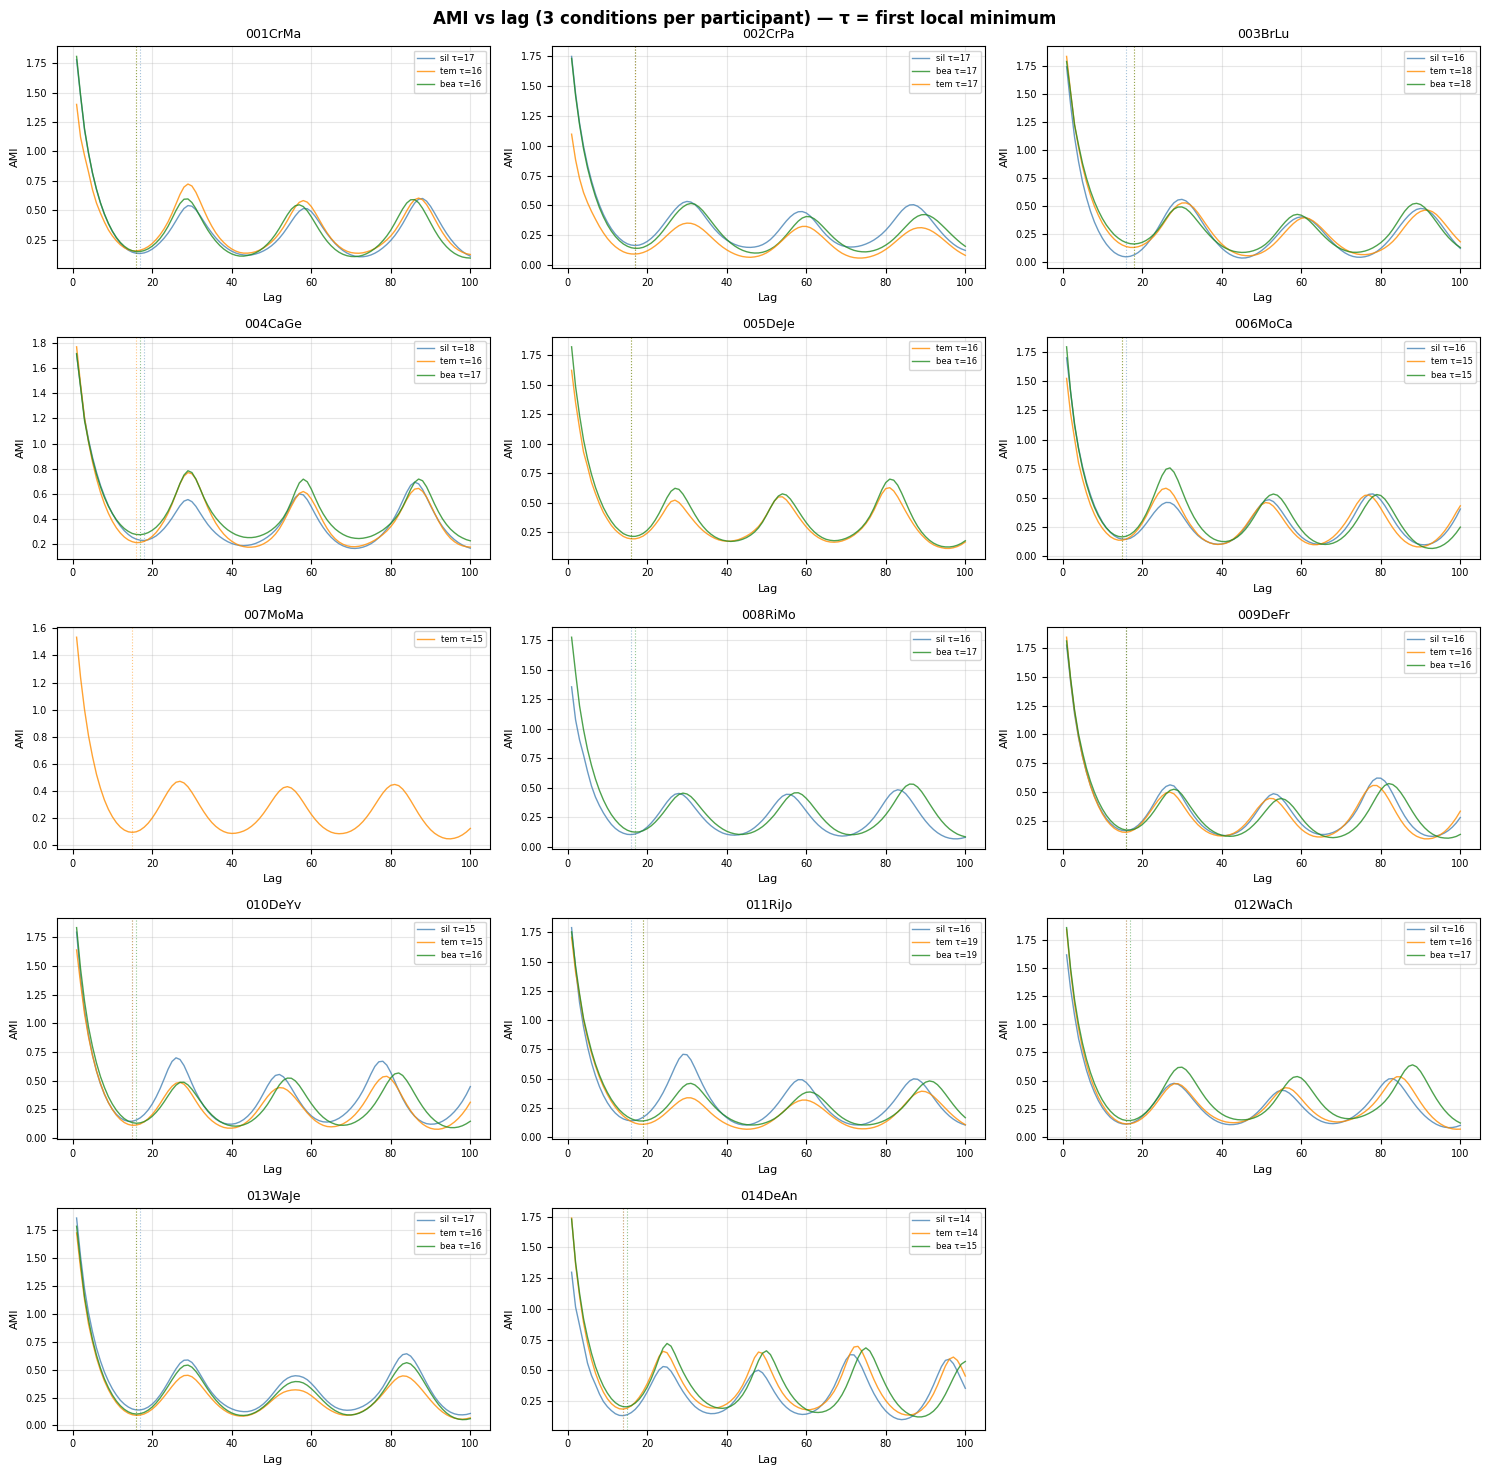

In [6]:
plots.plot_ami_curves(curves, save_to=OUT_FIGURES / '03_ami_curves.png')
plt.show()

   ✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\03_fnn_curves.png


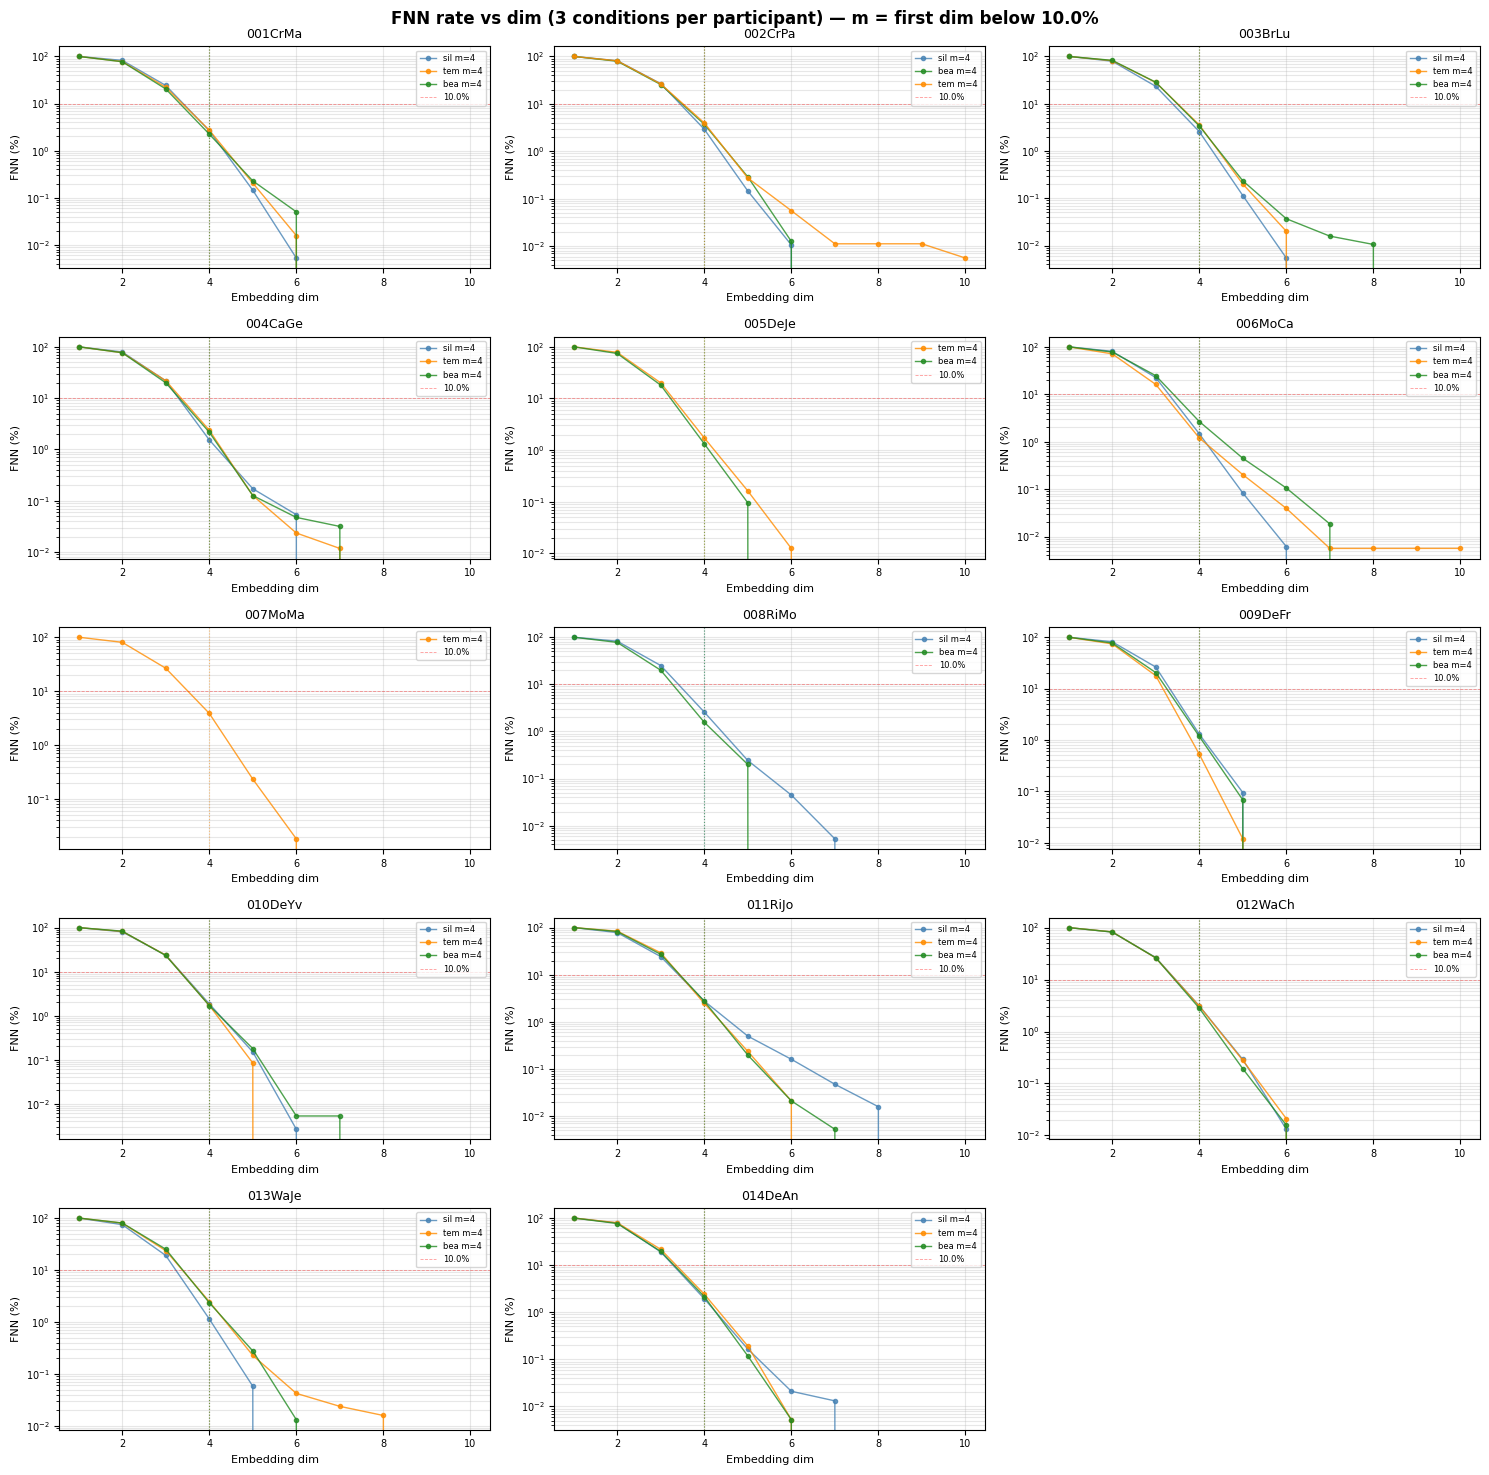

In [7]:
plots.plot_fnn_curves(curves, fnn_threshold=tde_workflow.FNN_THRESHOLD,
                       save_to=OUT_FIGURES / '03_fnn_curves.png')
plt.show()

   ✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\03_distributions.png


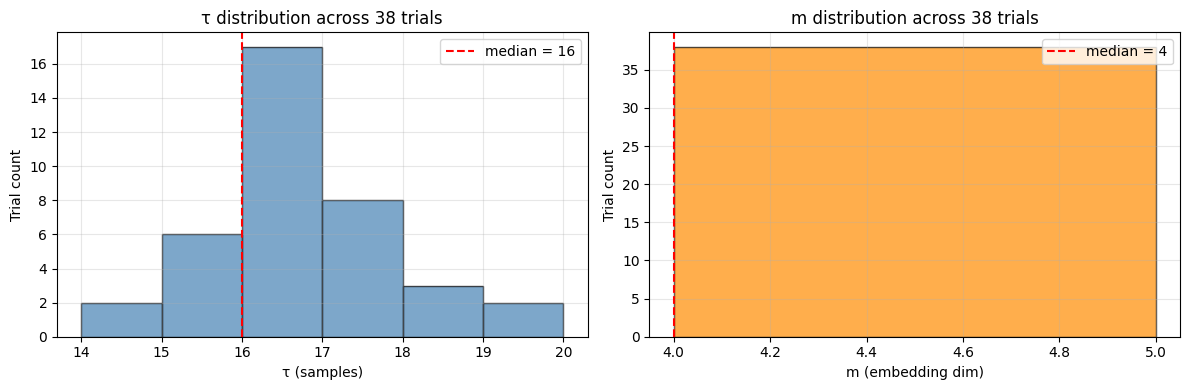

In [8]:
plots.plot_tde_distributions(df_tde, save_to=OUT_FIGURES / '03_distributions.png')
plt.show()

## 4. Export

In [9]:
p_trial, p_part = tde_workflow.export(df_tde, df_p)
print(f"✅ Exported:\n   {p_trial}\n   {p_part}")

✅ Exported:
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\03_tde_per_trial.csv
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\03_tde_per_participant.csv
